# UCR Dataset Analysis

Analyze individual UCR datasets used in the ROCKET benchmark: inspect their properties,
class distributions, time series shapes, and per-dataset classifier performance.

In [1]:
import sys
import os

sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from aeon.datasets import load_classification
from collections import Counter

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

## Configuration

Select which UCR datasets to analyze. Set `DATASETS` to a subset or use the full list from config.

In [2]:
from config import DATASETS as ALL_DATASETS

# Select datasets to analyze (set to ALL_DATASETS to use all)
DATASETS = ALL_DATASETS

# Path to benchmark results (set to None to skip classifier performance sections)
RESULTS_CSV = None

print(f"Datasets to analyze: {DATASETS}")

I0000 00:00:1774726480.222942   36622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774726480.228187   36622 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774726480.713010   36622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774726484.163375   36622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

Datasets to analyze: ['Computers', 'MiddlePhalanxOutlineCorrect', 'WormsTwoClass', 'Worms', 'Earthquakes', 'EMOPain', 'EthanolLevel', 'Chinatown', 'ECG200', 'CBF', 'SwedishLeaf', 'SyntheticControl', 'Beef', 'Trace', 'Wafer', 'TwoPatterns']


## 1. Load Datasets & Summary Table

In [3]:
dataset_info = []
loaded_data = {}

for name in DATASETS:
    X_train, y_train = load_classification(name, split="train")
    X_test, y_test = load_classification(name, split="test")
    X = np.concatenate([X_train, X_test], axis=0)
    y = np.concatenate([y_train, y_test], axis=0)

    loaded_data[name] = (X, y, X_train, y_train, X_test, y_test)

    classes = np.unique(y)
    class_counts = Counter(y)
    majority_ratio = max(class_counts.values()) / len(y)

    dataset_info.append({
        "Dataset": name,
        "Train samples": len(y_train),
        "Test samples": len(y_test),
        "Total samples": len(y),
        "Series length": X.shape[2],
        "Channels": X.shape[1],
        "Classes": len(classes),
        "Class labels": ", ".join(sorted(classes)),
        "Majority ratio": round(majority_ratio, 3),
    })

info_df = pd.DataFrame(dataset_info).set_index("Dataset")
info_df

,Train samples,Test samples,Total samples,Series length,Channels,Classes,Class labels,Majority ratio
Dataset,,,,,,,,
Computers,250,250,500,720,1,2,"1, 2",0.500
MiddlePhalanxOutlineCorrect,600,291,891,80,1,2,"0, 1",0.622
WormsTwoClass,181,77,258,900,1,2,"1, 2",0.578
Worms,181,77,258,900,1,5,"1, 2, 3, 4, 5",0.422
Earthquakes,322,139,461,512,1,2,"0, 1",0.798
EMOPain,968,355,1323,200,30,3,"0, 1, 2",0.772
EthanolLevel,504,500,1004,1751,1,4,"1, 2, 3, 4",0.251
Chinatown,20,343,363,24,1,2,"1, 2",0.713
ECG200,100,100,200,96,1,2,"-1, 1",0.665


## 2. Class Distribution

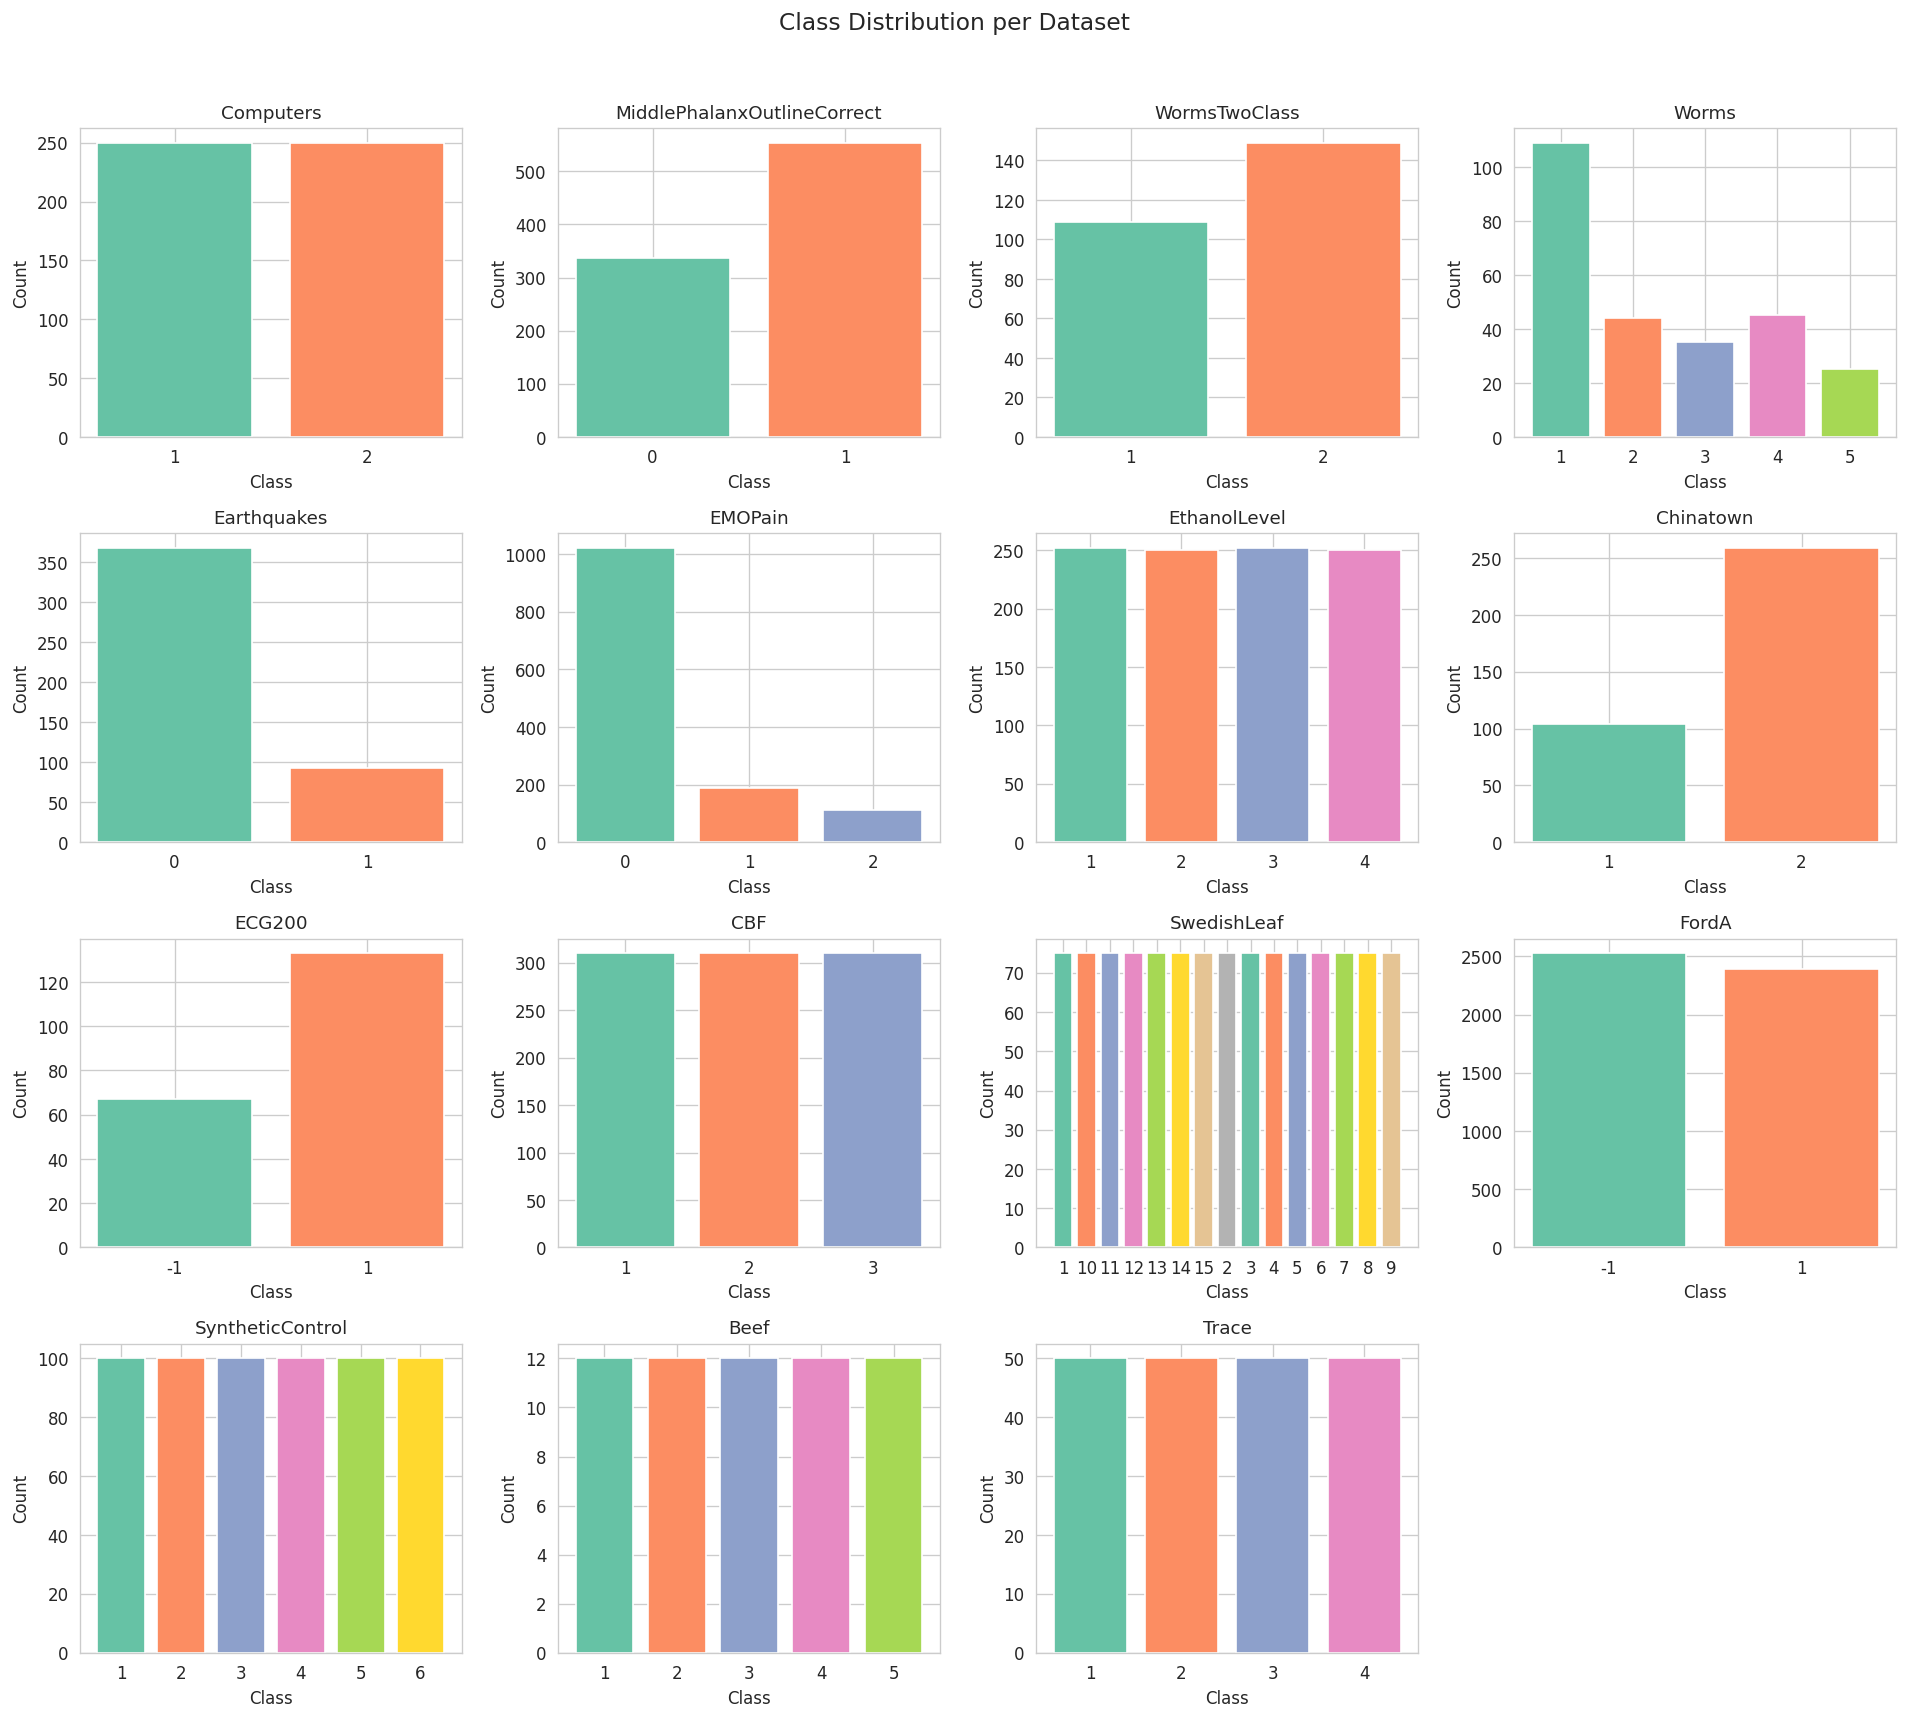

In [5]:
n = len(DATASETS)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
axes = np.array(axes).flatten() if n > 1 else [axes]

for i, name in enumerate(DATASETS):
    _, y, _, _, _, _ = loaded_data[name]
    counts = Counter(y)
    labels = sorted(counts.keys())
    values = [counts[l] for l in labels]

    axes[i].bar(labels, values, color=sns.color_palette("Set2", len(labels)))
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Count")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Class Distribution per Dataset", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 3. Train / Test Split Comparison

Check whether class proportions are preserved across the original train/test splits.

In [5]:
split_rows = []
for name in DATASETS:
    _, _, X_train, y_train, X_test, y_test = loaded_data[name]
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    classes = sorted(set(y_train) | set(y_test))
    for cls in classes:
        split_rows.append({
            "Dataset": name,
            "Class": cls,
            "Train count": train_counts.get(cls, 0),
            "Train %": round(train_counts.get(cls, 0) / len(y_train) * 100, 1),
            "Test count": test_counts.get(cls, 0),
            "Test %": round(test_counts.get(cls, 0) / len(y_test) * 100, 1),
        })

split_df = pd.DataFrame(split_rows)
split_df

,Dataset,Class,Train count,Train %,Test count,Test %
0,Computers,1,125,50.0,125,50.0
1,Computers,2,125,50.0,125,50.0
2,HandOutlines,0,362,36.2,133,35.9
3,HandOutlines,1,638,63.8,237,64.1
4,MiddlePhalanxOutlineCorrect,0,212,35.3,125,43.0
5,MiddlePhalanxOutlineCorrect,1,388,64.7,166,57.0
6,WormsTwoClass,1,76,42.0,33,42.9
7,WormsTwoClass,2,105,58.0,44,57.1
8,Worms,1,76,42.0,33,42.9
9,Worms,2,31,17.1,13,16.9


## 4. Sample Time Series Visualization

Plot a few example time series from each class for every dataset.

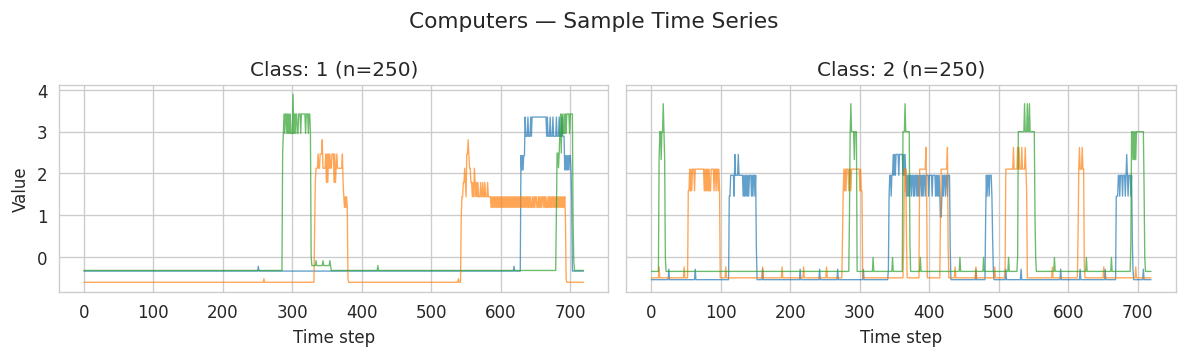

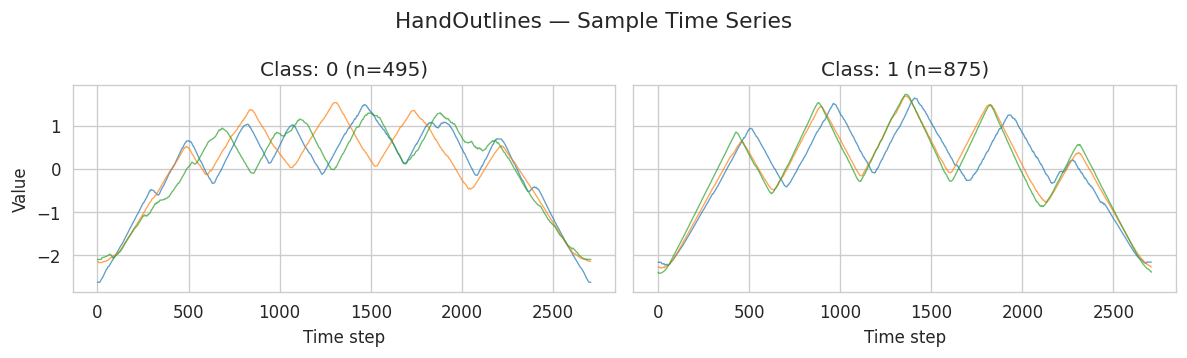

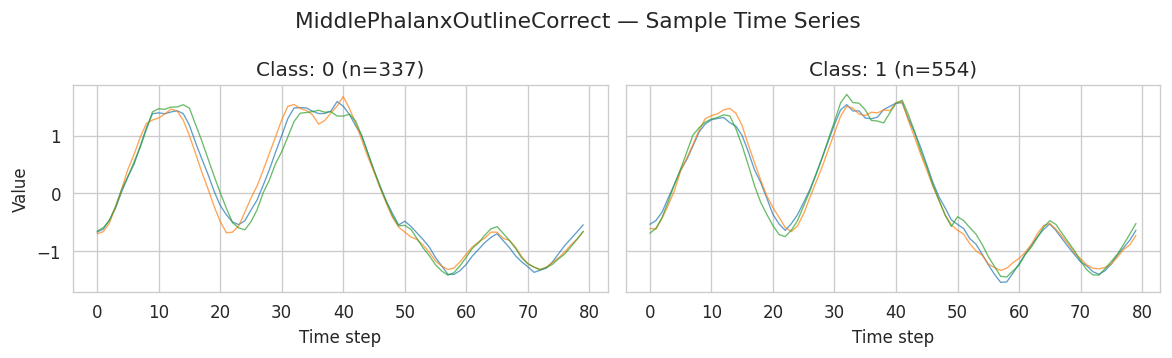

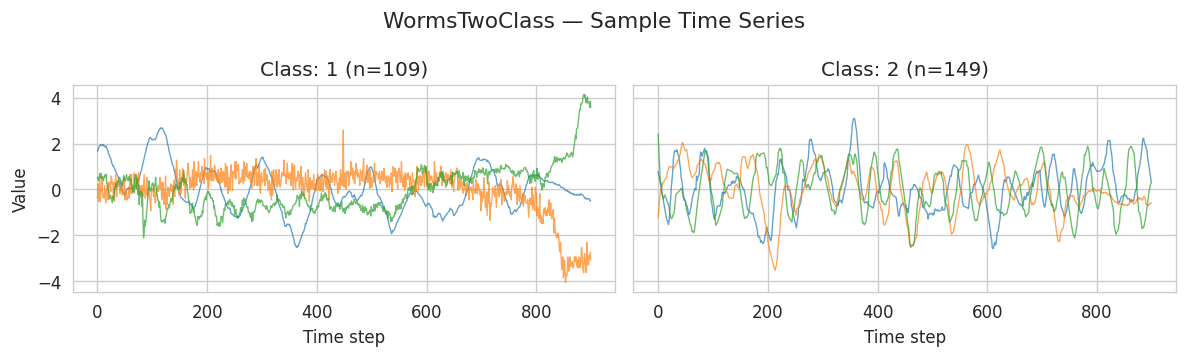

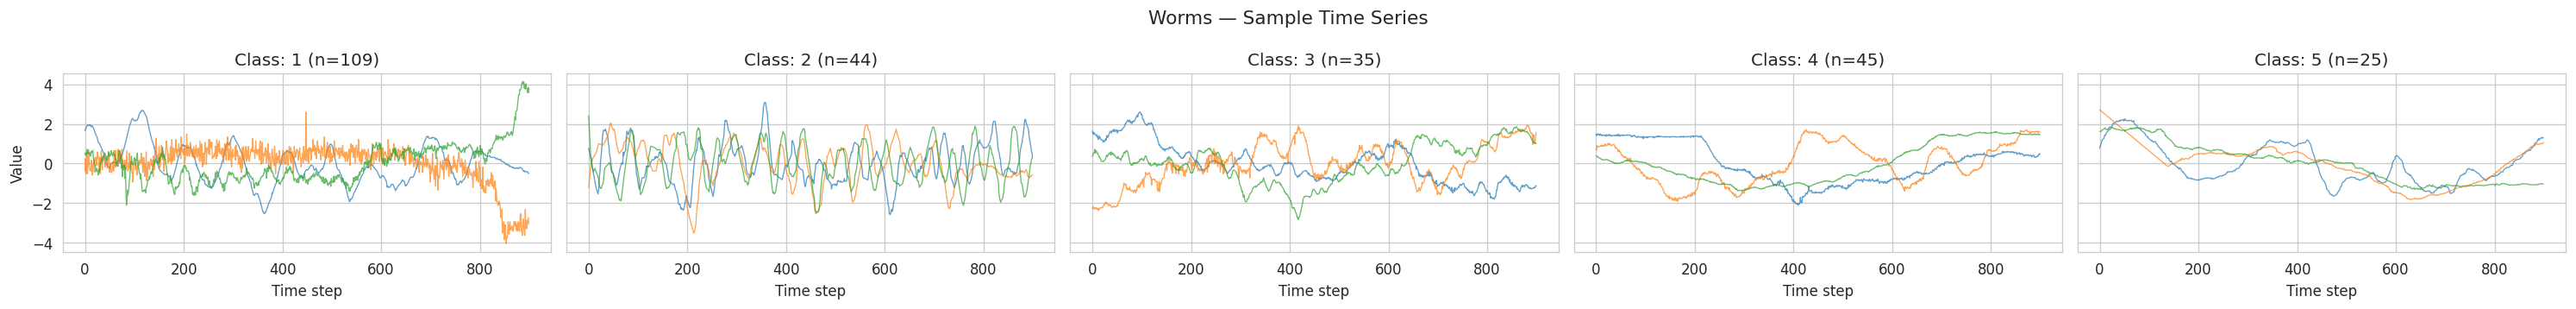

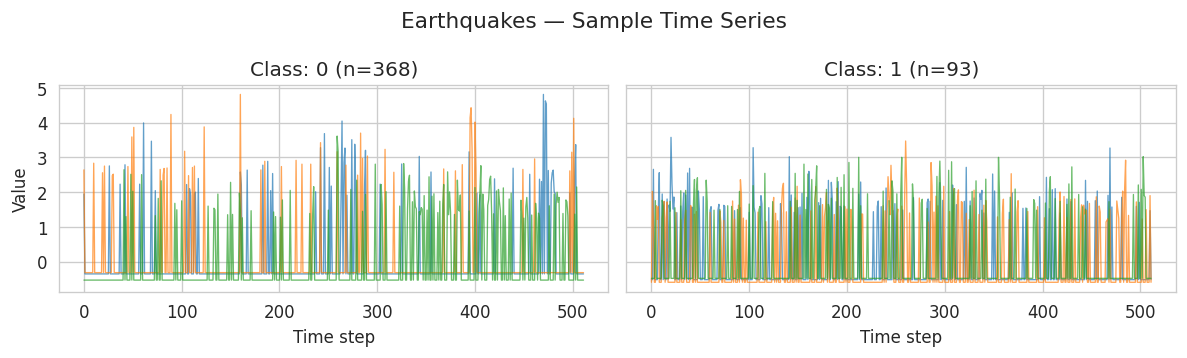

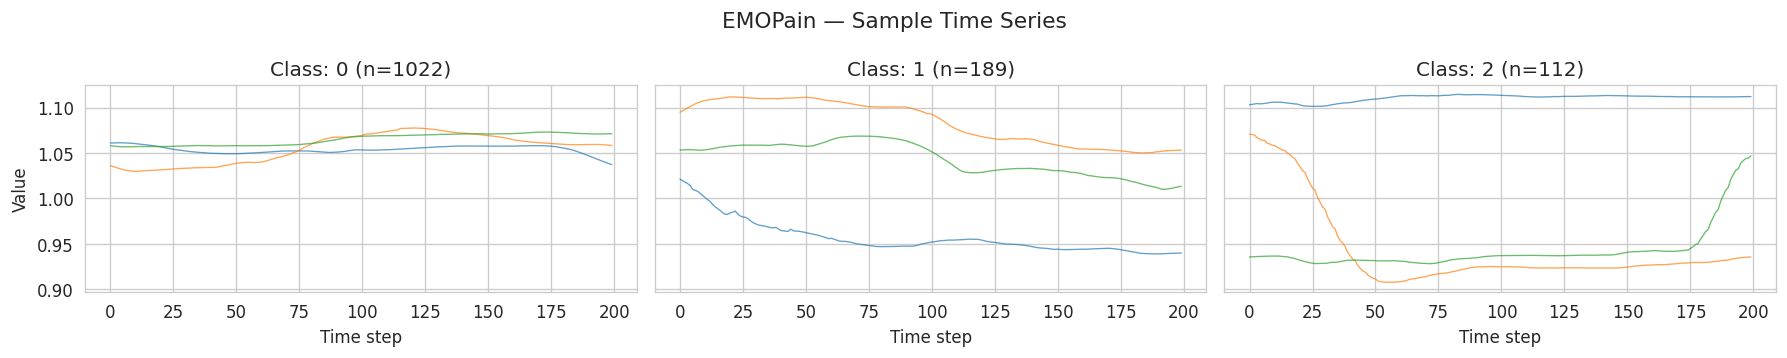

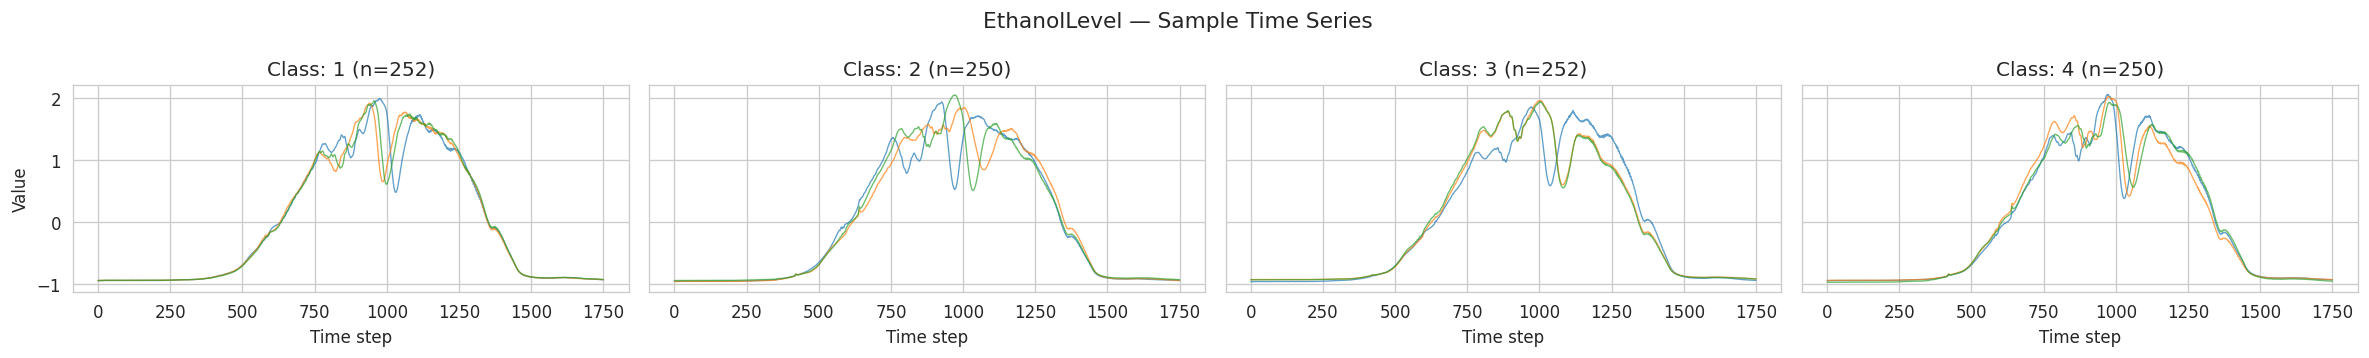

In [6]:
SAMPLES_PER_CLASS = 3

for name in DATASETS:
    X, y, _, _, _, _ = loaded_data[name]
    classes = sorted(np.unique(y))
    n_classes = len(classes)

    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 3), sharey=True)
    if n_classes == 1:
        axes = [axes]

    for ax, cls in zip(axes, classes):
        idx = np.where(y == cls)[0]
        sample_idx = idx[:SAMPLES_PER_CLASS]
        for si in sample_idx:
            ax.plot(X[si, 0, :], alpha=0.7, linewidth=0.8)
        ax.set_title(f"Class: {cls} (n={len(idx)})")
        ax.set_xlabel("Time step")

    axes[0].set_ylabel("Value")
    fig.suptitle(f"{name} — Sample Time Series", fontsize=13)
    fig.tight_layout()
    plt.show()

## 5. Per-Class Mean and Spread

Plot mean ± 1 std for each class to visualize discriminability.

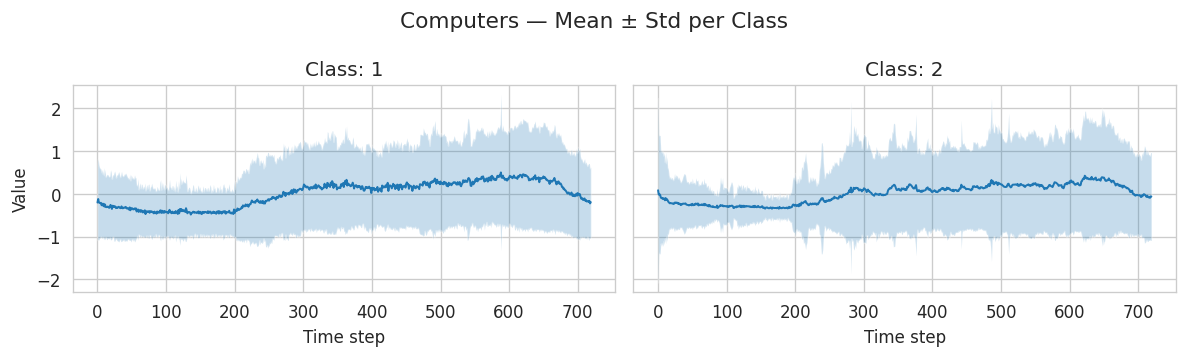

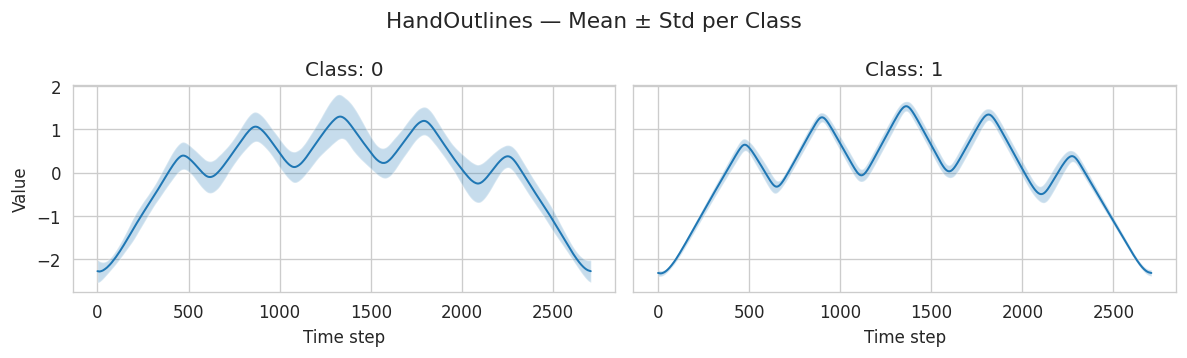

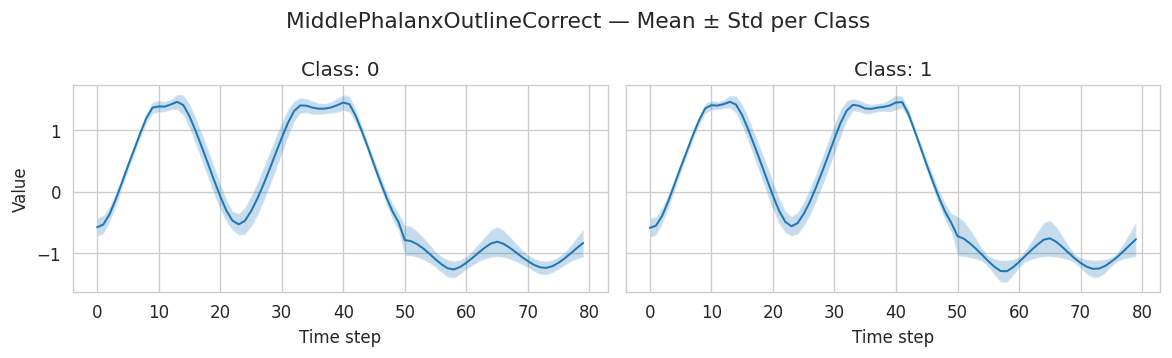

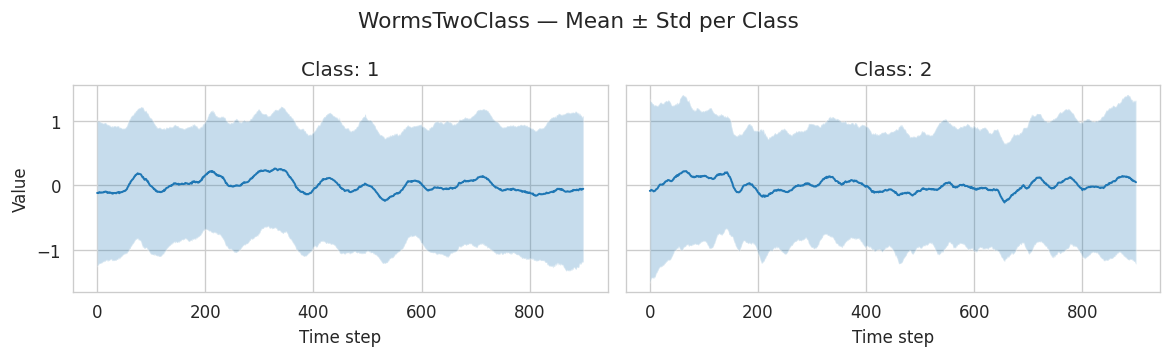

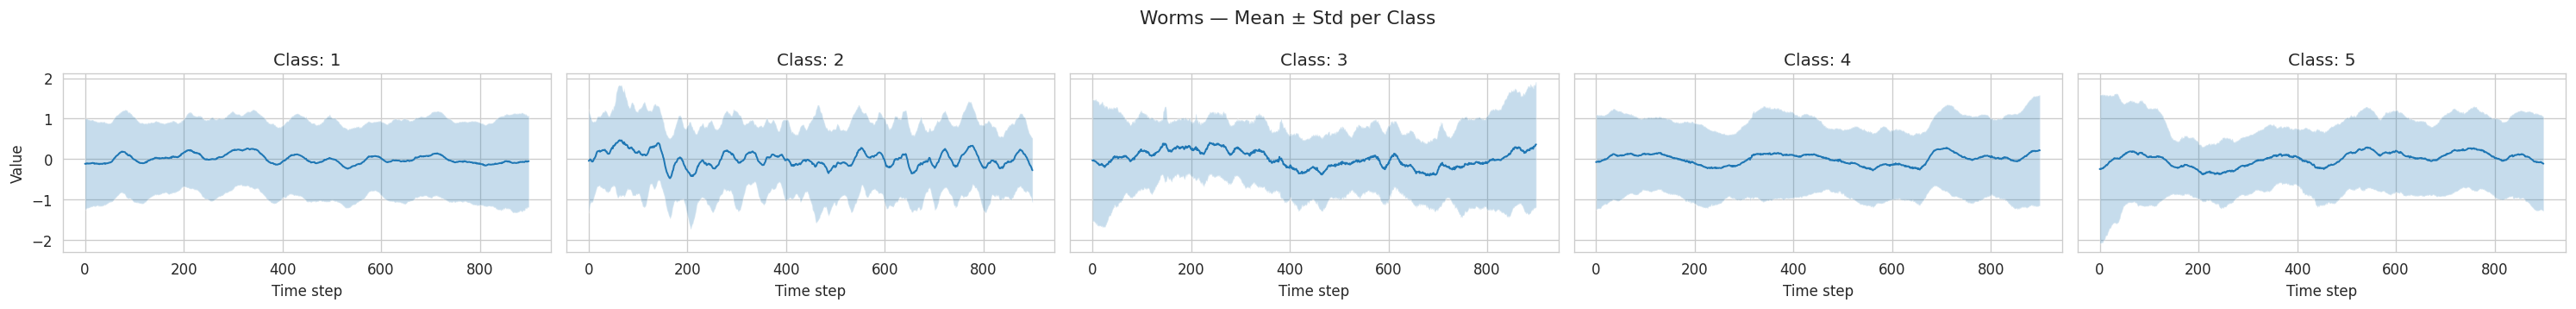

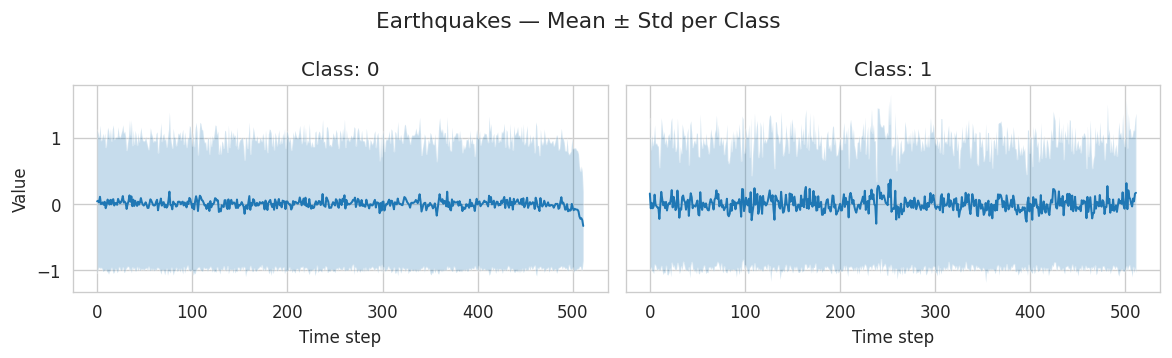

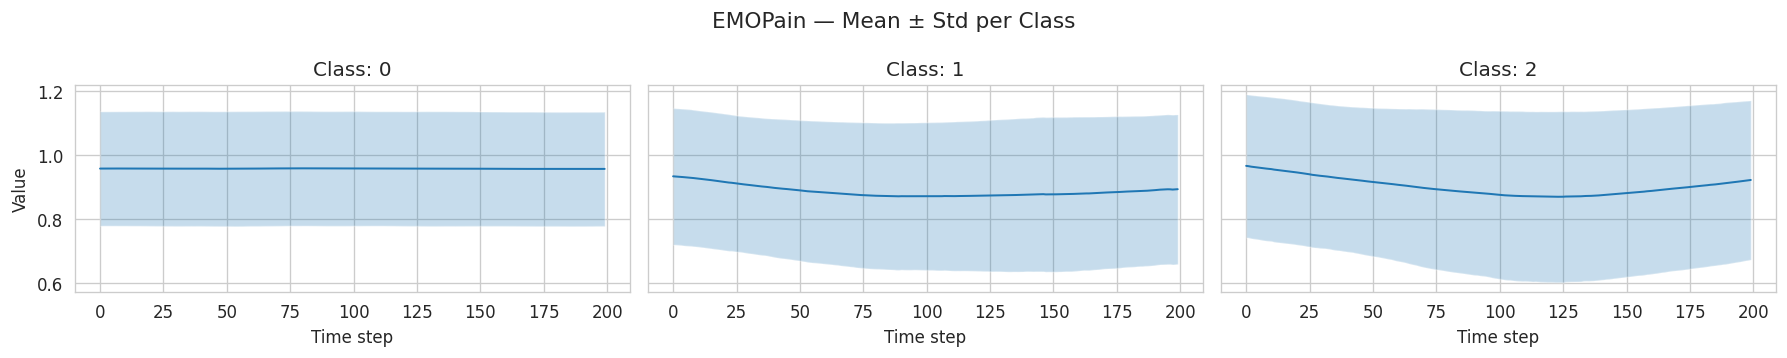

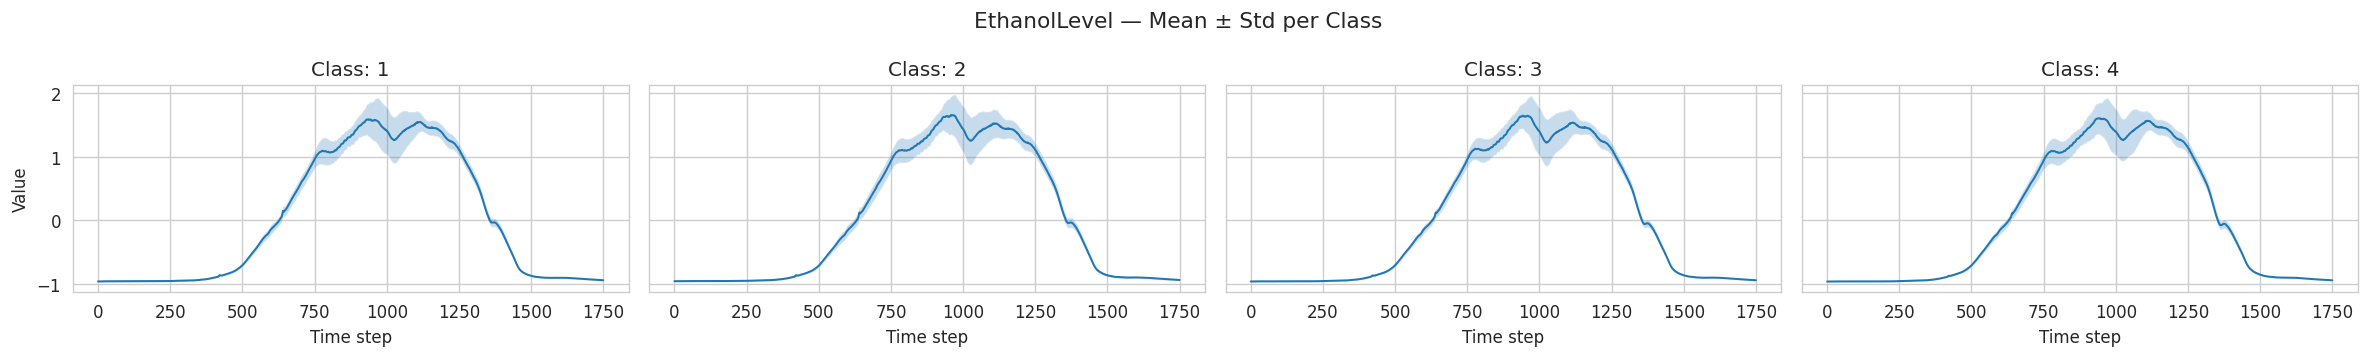

In [7]:
for name in DATASETS:
    X, y, _, _, _, _ = loaded_data[name]
    classes = sorted(np.unique(y))
    n_classes = len(classes)

    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 3), sharey=True)
    if n_classes == 1:
        axes = [axes]

    for ax, cls in zip(axes, classes):
        class_data = X[y == cls, 0, :]
        mean = class_data.mean(axis=0)
        std = class_data.std(axis=0)
        t = np.arange(len(mean))
        ax.plot(t, mean, linewidth=1.2)
        ax.fill_between(t, mean - std, mean + std, alpha=0.25)
        ax.set_title(f"Class: {cls}")
        ax.set_xlabel("Time step")

    axes[0].set_ylabel("Value")
    fig.suptitle(f"{name} — Mean ± Std per Class", fontsize=13)
    fig.tight_layout()
    plt.show()

## 6. Basic Statistics per Dataset

Global value range, mean, std, and missing values for each dataset.

In [8]:
stats_rows = []
for name in DATASETS:
    X, y, _, _, _, _ = loaded_data[name]
    vals = X[:, 0, :]  # first channel
    stats_rows.append({
        "Dataset": name,
        "Min": round(np.nanmin(vals), 4),
        "Max": round(np.nanmax(vals), 4),
        "Mean": round(np.nanmean(vals), 4),
        "Std": round(np.nanstd(vals), 4),
        "NaN count": int(np.isnan(vals).sum()),
    })

pd.DataFrame(stats_rows).set_index("Dataset")

,Min,Max,Mean,Std,NaN count
Dataset,,,,,
Computers,-3.7477,26.3867,-0.0000,0.9993,0
HandOutlines,-3.2180,2.0902,-0.0000,0.9998,0
MiddlePhalanxOutlineCorrect,-1.7195,2.0673,0.0000,0.9937,0
WormsTwoClass,-4.8873,4.8591,0.0000,0.9994,0
Worms,-4.8873,4.8591,0.0000,0.9994,0
Earthquakes,-0.8858,7.8634,0.0000,0.9990,0
EMOPain,0.0004,1.2837,0.9426,0.1953,0
EthanolLevel,-0.9932,2.0754,-0.0000,1.0000,0


## 7. Series Length Distribution

Compare the time series lengths across datasets.

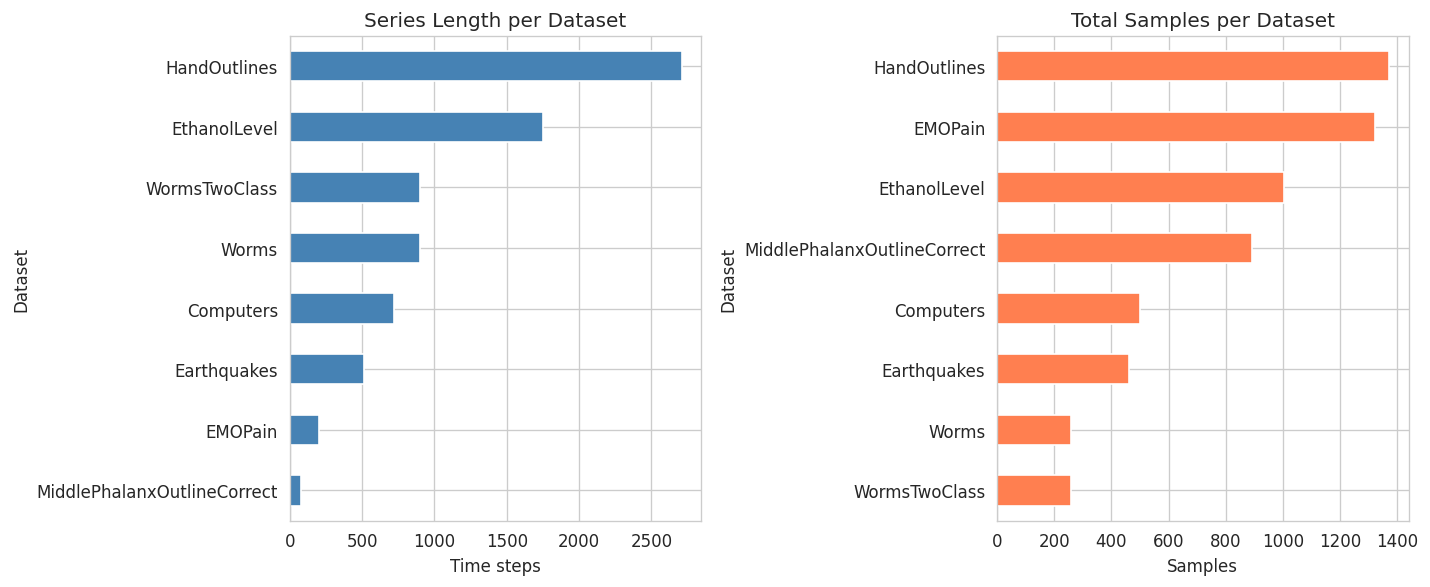

In [9]:
length_data = info_df[["Total samples", "Series length", "Classes"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Series length
length_data["Series length"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_xlabel("Time steps")
axes[0].set_title("Series Length per Dataset")

# Total samples
length_data["Total samples"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_xlabel("Samples")
axes[1].set_title("Total Samples per Dataset")

fig.tight_layout()
plt.show()

## 8. Classifier Performance per Dataset

If benchmark results are available, show how each classifier performs on each dataset.

In [ ]:
if RESULTS_CSV and os.path.exists(RESULTS_CSV):
    results_df = pd.read_csv(RESULTS_CSV)
    results_df = results_df[results_df["dataset"].isin(DATASETS)]
    print(f"Loaded {len(results_df)} result rows for {results_df['dataset'].nunique()} datasets")
    results_df.head()
else:
    results_df = None
    print("No benchmark results found — skipping classifier performance sections.")

In [ ]:
if results_df is not None:
    mean_acc = results_df.groupby(["dataset", "classifier"])["accuracy"].mean().unstack()

    fig, ax = plt.subplots(figsize=(12, max(4, len(DATASETS) * 0.7)))
    sns.heatmap(mean_acc, annot=True, fmt=".3f", cmap="YlGn", ax=ax,
                linewidths=0.5, vmin=0.5, vmax=1.0)
    ax.set_title("Mean Accuracy per Dataset × Classifier")
    ax.set_ylabel("")
    ax.set_xlabel("")
    fig.tight_layout()
    plt.show()

In [ ]:
if results_df is not None:
    for name in DATASETS:
        sub = results_df[results_df["dataset"] == name]
        if sub.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Accuracy boxplot
        order = sub.groupby("classifier")["accuracy"].mean().sort_values(ascending=False).index
        sns.boxplot(data=sub, x="classifier", y="accuracy", order=order, ax=axes[0])
        axes[0].set_title(f"{name} — Accuracy across Folds")
        axes[0].tick_params(axis="x", rotation=45)
        axes[0].set_xlabel("")

        # Fit time bar
        fit_times = sub.groupby("classifier")["fit_time_s"].mean().loc[order]
        fit_times.plot.bar(ax=axes[1], color="steelblue")
        axes[1].set_title(f"{name} — Mean Fit Time")
        axes[1].set_ylabel("Seconds")
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].set_xlabel("")

        fig.tight_layout()
        plt.show()

## 9. Multi-Metric Comparison

Compare accuracy, balanced accuracy, F1, and Cohen's kappa across datasets.

In [ ]:
if results_df is not None:
    metrics = ["accuracy", "balanced_accuracy", "f1_weighted", "cohen_kappa"]

    metric_summary = results_df.groupby("dataset")[metrics].mean()

    fig, ax = plt.subplots(figsize=(10, max(4, len(DATASETS) * 0.6)))
    metric_summary.plot.barh(ax=ax)
    ax.set_xlabel("Score")
    ax.set_title("Mean Metrics per Dataset (averaged over all classifiers and folds)")
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()

    metric_summary.round(4)

## 10. Dataset Difficulty Ranking

Rank datasets by how hard they are for classifiers (mean accuracy across all classifiers).

In [ ]:
if results_df is not None:
    difficulty = results_df.groupby("dataset")["accuracy"].agg(["mean", "std"]).sort_values("mean")
    difficulty.columns = ["Mean accuracy", "Std accuracy"]

    fig, ax = plt.subplots(figsize=(8, max(3, len(DATASETS) * 0.5)))
    ax.barh(difficulty.index, difficulty["Mean accuracy"], xerr=difficulty["Std accuracy"],
            color="steelblue", capsize=3)
    ax.set_xlabel("Mean Accuracy (± std)")
    ax.set_title("Dataset Difficulty Ranking (lower = harder)")
    ax.set_xlim(0, 1)
    fig.tight_layout()
    plt.show()

    difficulty.round(4)